# Hafta 13: Makine Öğrenmesi II: Denetimli Sınıflandırma ve Model Değerlendirme — Promotör Tahmini

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Eğitim/test ayrımı, aşırı öğrenme (overfitting) ve çapraz doğrulama kavramlarını uygulamak.
2. k-NN, lojistik regresyon, karar ağacı ve rastgele ormanın çalışma mantığını elle çözülmüş örneklerle anlamak.
3. Karışıklık matrisi, doğruluk, kesinlik, duyarlılık, F1, ROC–AUC ölçütlerini hesaplamak ve yorumlamak.
4. DNA dizilerinden k-mer ve motif özellikleri çıkararak **promotör / promotör değil** sınıflandırıcısı kurmak ve modeli yorumlamak.

**Veri:** `promotor_veriseti.csv` — 2000 adet 80 bp sentetik dizi (1000 promotör, 1000 promotör değil)

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_promotor(klasor="veri"):
    """promotor_veriseti.csv: 2000 adet 80 bp dizi, etiket 1=promotor, 0=promotor değil"""
    import os, random, csv
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(21)
    tata_pwm = [  # TATAAA benzeri motif için pozisyon ağırlık matrisi (A,C,G,T)
        [0.05, 0.05, 0.05, 0.85], [0.85, 0.05, 0.05, 0.05], [0.10, 0.05, 0.05, 0.80],
        [0.80, 0.05, 0.05, 0.10], [0.70, 0.05, 0.05, 0.20], [0.75, 0.05, 0.10, 0.10]]
    def bg(n, gc):
        return "".join(rng.choices("ACGT", weights=[(1 - gc) / 2, gc / 2, gc / 2, (1 - gc) / 2], k=n))
    def motif():
        return "".join(rng.choices("ACGT", weights=w)[0] for w in tata_pwm)
    satirlar = []
    for i in range(2000):
        pozitif = i % 2 == 0
        if pozitif:
            s = list(bg(80, rng.uniform(0.48, 0.62)))
            if rng.random() < 0.80:
                p = rng.randint(22, 34)
                s[p:p + 6] = motif()
            if rng.random() < 0.50:
                p = rng.randint(2, 15)
                s[p:p + 6] = "GGGCGG"
        else:
            s = list(bg(80, rng.uniform(0.38, 0.55)))
            if rng.random() < 0.20:
                p = rng.randint(0, 74)
                s[p:p + 6] = motif()
        satirlar.append((f"dizi_{i+1:04d}", "".join(s), int(pozitif)))
    rng.shuffle(satirlar)
    with open(os.path.join(klasor, "promotor_veriseti.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["id", "dizi", "etiket"])
        w.writerows(satirlar)


if not os.path.exists('veri/promotor_veriseti.csv'):
    veri_uret_promotor()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'promotor_veriseti.csv']


## 1. Denetimli öğrenme akışı
```
Etiketli veri (dizi, etiket)
   → Özellik çıkarımı → EĞİTİM kümesi (%80)  →  model.fit()  → hiperparametre seçimi (çapraz doğrulama)
                      → TEST kümesi (%20)    →  model.predict() → SADECE EN SONDA bir kez değerlendirme
```
**Altın kural:** Test verisi, model geliştirme sürecinin hiçbir aşamasında (özellik seçimi, ölçekleme, parametre ayarı) kullanılmaz.

| Kavram | Belirti | Çözüm |
|---|---|---|
| Az öğrenme (underfitting) | Eğitim ve test başarısı düşük | Daha karmaşık model, daha iyi özellikler |
| Aşırı öğrenme (overfitting) | Eğitim çok yüksek, test düşük | Düzenlileştirme, daha fazla veri, daha basit model |

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, itertools
from collections import Counter

veri = pd.read_csv("veri/promotor_veriseti.csv")
print(veri.shape, "| sınıf dağılımı:", veri.etiket.value_counts().to_dict())
veri.head()

(2000, 3) | sınıf dağılımı: {0: 1000, 1: 1000}


,id,dizi,etiket
0,dizi_0696,CTTTGCACAAATCCCCTGAATGAGCTCGATGGGGTCCATCCCCCGC...,0
1,dizi_1881,GCGGGCAGTATGGGGCGGGTCGCCTTTAAACTTTGAGGCCATCTAT...,1
2,dizi_0100,CACAATTAGTTCCGTATAAAGTACAAGATTTTAGGCAAATCGGGCA...,0
3,dizi_0594,AGGCAACGTTACGAGCTGATTAAAGTGTTAATTGTTACATGGTCCT...,0
4,dizi_1232,GTGGAGACAACAGATCCGCAACTACTGGTAAAGCATCGCGTGCGGC...,0


## 2. Özellik çıkarımı: k-mer frekansları + motif skoru

Özellik boyutları: k=1: (2000, 4) k=2: (2000, 16) k=3: (2000, 64) k=4: (2000, 256)


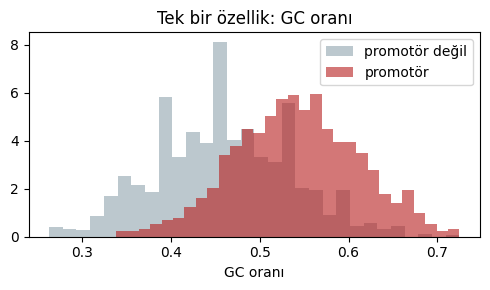

In [4]:
def kmer_ozellikleri(diziler, k):
    kelimeler = ["".join(p) for p in itertools.product("ACGT", repeat=k)]
    ind = {w: i for i, w in enumerate(kelimeler)}
    X = np.zeros((len(diziler), len(kelimeler)))
    for r, s in enumerate(diziler):
        for i in range(len(s) - k + 1):
            X[r, ind[s[i:i + k]]] += 1
    return X / X.sum(axis=1, keepdims=True), kelimeler

X1, ad1 = kmer_ozellikleri(veri.dizi, 1)
X2, ad2 = kmer_ozellikleri(veri.dizi, 2)
X3, ad3 = kmer_ozellikleri(veri.dizi, 3)
X4, ad4 = kmer_ozellikleri(veri.dizi, 4)
y = veri.etiket.values
print("Özellik boyutları: k=1:", X1.shape, "k=2:", X2.shape, "k=3:", X3.shape, "k=4:", X4.shape)

gc = X1[:, 1] + X1[:, 2]
plt.figure(figsize=(5, 3))
plt.hist(gc[y == 0], bins=30, alpha=0.6, color="#90a4ae", label="promotör değil", density=True)
plt.hist(gc[y == 1], bins=30, alpha=0.6, color="#b71c1c", label="promotör", density=True)
plt.xlabel("GC oranı"); plt.legend(); plt.title("Tek bir özellik: GC oranı"); plt.tight_layout(); plt.show()

In [5]:
from Bio import motifs
from Bio.Seq import Seq
tata = motifs.create([Seq(s) for s in ["TATAAA", "TATAAA", "TATATA", "TATAAT", "TATAAG"]])
pssm = tata.counts.normalize(pseudocounts=0.5).log_odds()

def motif_ozellikleri(s):
    skor = pssm.calculate(Seq(s))
    return [skor.max(), (skor > 5).sum(), int("GGGCGG" in s)]

Xm = np.array([motif_ozellikleri(s) for s in veri.dizi])
print("Motif özellikleri (maks. TATA skoru, eşik üstü sayısı, GC-kutusu var mı):\n", Xm[:5].round(2))

Motif özellikleri (maks. TATA skoru, eşik üstü sayısı, GC-kutusu var mı):
 [[2.7  0.   0.  ]
 [5.8  2.   1.  ]
 [8.97 2.   0.  ]
 [5.8  1.   0.  ]
 [2.05 0.   0.  ]]


## 3. Eğitim / test ayrımı
`stratify=y`: sınıf oranları her iki kümede de korunur.

In [6]:
from sklearn.model_selection import train_test_split
X_tum = np.hstack([X3, Xm])
ozellik_adlari = ad3 + ["TATA_maks", "TATA_sayi", "GC_kutusu"]
X_egt, X_test, y_egt, y_test, i_egt, i_test = train_test_split(X_tum, y, np.arange(len(y)), test_size=0.2, stratify=y, random_state=42)
print("Eğitim:", X_egt.shape, "| Test:", X_test.shape, "| test sınıf oranı:", y_test.mean())

Eğitim: (1600, 67) | Test: (400, 67) | test sınıf oranı: 0.5


## 4. Modeller — mantık ve elle örnekler

### 4.1 k-En Yakın Komşu (k-NN)
Yeni bir örnek, eğitimdeki en yakın *k* örneğin çoğunluk sınıfına atanır. **Eğitim yok**, tahmin pahalı; ölçeklemeye duyarlı.

**Örnek (tek özellik: GC oranı):** Eğitim: (0.40, 0), (0.45, 0), (0.50, 1), (0.55, 1), (0.60, 1). Yeni örnek GC = 0.47, k = 3:
uzaklıklar 0.07, 0.02, 0.03, 0.08, 0.13 → en yakın 3: 0.45(0), 0.50(1), 0.40(0) → **sınıf 0** (2'ye 1).

### 4.2 Lojistik regresyon
$P(y=1\mid x) = \sigma(z) = \dfrac{1}{1+e^{-z}}$, &nbsp; $z = w^Tx + b$. Ağırlıklar **log-kayıp** (çapraz entropi) en küçüklenerek öğrenilir:
$\mathcal{L} = -\frac{1}{n}\sum [y\log p + (1-y)\log(1-p)]$.

**Örnek:** w = (2.0 [TATA var], 1.5 [GC]), b = −1.0. x = (1, 0.6): z = 2 + 0.9 − 1 = 1.9 → p = σ(1.9) = **0.870** → promotör.
x = (0, 0.4): z = 0 + 0.6 − 1 = −0.4 → p = 0.401 → promotör değil. Gerçek etiket 1 ise ilk örneğin kaybı −ln(0.870) = 0.139.

### 4.3 Karar ağacı ve Gini safsızlığı
$G = 1 - \sum_k p_k^2$. Her düğümde safsızlığı en çok azaltan bölme seçilir.

**Örnek:** Düğüm: 10 promotör + 10 değil → G = 1 − 0.5² − 0.5² = 0.5.
Bölme "TATA var mı?": sol (var) 8+/2−: G = 1 − 0.64 − 0.04 = 0.32; sağ (yok) 2+/8−: G = 0.32.
Ağırlıklı G = 0.5·0.32 + 0.5·0.32 = 0.32 → **kazanç = 0.5 − 0.32 = 0.18**.

### 4.4 Rastgele orman
Çok sayıda karar ağacı; her biri **bootstrap** örneğiyle ve her bölmede **rastgele özellik alt kümesiyle** eğitilir, sonuç oylamayla belirlenir.
Varyansı düşürür, aşırı öğrenmeye dirençlidir, özellik önemleri verir.

In [7]:
sig = lambda z: 1 / (1 + np.exp(-z))
print("LR örneği: p1 =", round(sig(2 * 1 + 1.5 * 0.6 - 1), 3), "| p2 =", round(sig(2 * 0 + 1.5 * 0.4 - 1), 3), "| kayıp1 =", round(-np.log(sig(1.9)), 3))
gini = lambda *n: 1 - sum((x / sum(n)) ** 2 for x in n)
print("Gini: kök =", gini(10, 10), "| sol =", round(gini(8, 2), 2), "| kazanç =", round(gini(10, 10) - (0.5 * gini(8, 2) + 0.5 * gini(2, 8)), 2))

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3).fit([[0.40], [0.45], [0.50], [0.55], [0.60]], [0, 0, 1, 1, 1])
print("k-NN örneği: GC=0.47 ->", knn.predict([[0.47]])[0])

LR örneği: p1 = 0.87 | p2 = 0.401 | kayıp1 = 0.139
Gini: kök = 0.5 | sol = 0.32 | kazanç = 0.18
k-NN örneği: GC=0.47 -> 0


In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

modeller = {
    "k-NN (k=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "Lojistik regresyon": make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000)),
    "Karar ağacı (derinlik sınırsız)": DecisionTreeClassifier(random_state=0),
    "Karar ağacı (derinlik 4)": DecisionTreeClassifier(max_depth=4, random_state=0),
    "Rastgele orman (300 ağaç)": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
}
satir = []
for ad, m in modeller.items():
    m.fit(X_egt, y_egt)
    satir.append({"model": ad, "eğitim doğruluğu": accuracy_score(y_egt, m.predict(X_egt)),
                  "test doğruluğu": accuracy_score(y_test, m.predict(X_test))})
pd.DataFrame(satir).set_index("model").round(3)

,eğitim doğruluğu,test doğruluğu
model,,
k-NN (k=15),0.806,0.785
Lojistik regresyon,0.836,0.808
Karar ağacı (derinlik sınırsız),1.000,0.710
Karar ağacı (derinlik 4),0.802,0.768
Rastgele orman (300 ağaç),1.000,0.815


> Sınırsız derinlikteki karar ağacının eğitim doğruluğu 1.0 iken test doğruluğu belirgin şekilde düşük: **aşırı öğrenme**.
Rastgele orman da eğitim verisini ezberliyor (1.0), ancak yüzlerce farklı ağacın oylaması varyansı düşürdüğü için test başarısı en yüksek
modellerden biri. Yani eğitim–test farkı tek başına yeterli değildir; asıl ölçüt **görülmemiş veride** başarıdır.

## 5. Değerlendirme ölçütleri

| | Tahmin: 1 | Tahmin: 0 |
|---|---|---|
| **Gerçek: 1** | TP | FN |
| **Gerçek: 0** | FP | TN |

| Ölçüt | Formül | Soru |
|---|---|---|
| Doğruluk | (TP+TN)/N | Ne kadarını doğru bildik? |
| Kesinlik (precision) | TP/(TP+FP) | "Promotör" dediklerimizin ne kadarı gerçekten promotör? |
| Duyarlılık (recall, TPR) | TP/(TP+FN) | Gerçek promotörlerin ne kadarını yakaladık? |
| Özgüllük (TNR) | TN/(TN+FP) | Negatiflerin ne kadarını doğru reddettik? |
| F1 | 2·P·R/(P+R) | Kesinlik ve duyarlılığın harmonik ortalaması |

### Sayısal örnek: TP = 40, FN = 20, FP = 10, TN = 130 (N = 200)
Doğruluk = 170/200 = **0.85**; Kesinlik = 40/50 = **0.80**; Duyarlılık = 40/60 = **0.667**; Özgüllük = 130/140 = **0.929**;
F1 = 2·0.8·0.667/(1.467) = **0.727**.

### ROC eğrisi ve AUC
Eşik 1'den 0'a indirilirken (FPR, TPR) noktaları çizilir. **AUC**, rastgele bir pozitifin rastgele bir negatiften daha yüksek skor alma olasılığıdır.

**Örnek:** Pozitif skorları {0.9, 0.8, 0.4}, negatif skorları {0.7, 0.3, 0.2}. 9 çiftten pozitifin kazandığı: 3 + 3 + 2 = 8 → **AUC = 8/9 = 0.889**.

In [9]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay, classification_report)
y_g = np.array([1] * 60 + [0] * 140)
y_t = np.array([1] * 40 + [0] * 20 + [1] * 10 + [0] * 130)
print("Elle örnek -> doğruluk", accuracy_score(y_g, y_t), "| kesinlik", precision_score(y_g, y_t),
      "| duyarlılık", round(recall_score(y_g, y_t), 3), "| F1", round(f1_score(y_g, y_t), 3))
print("AUC örneği:", round(roc_auc_score([1, 1, 1, 0, 0, 0], [0.9, 0.8, 0.4, 0.7, 0.3, 0.2]), 3))

Elle örnek -> doğruluk 0.85 | kesinlik 0.8 | duyarlılık 0.667 | F1 0.727
AUC örneği: 0.889


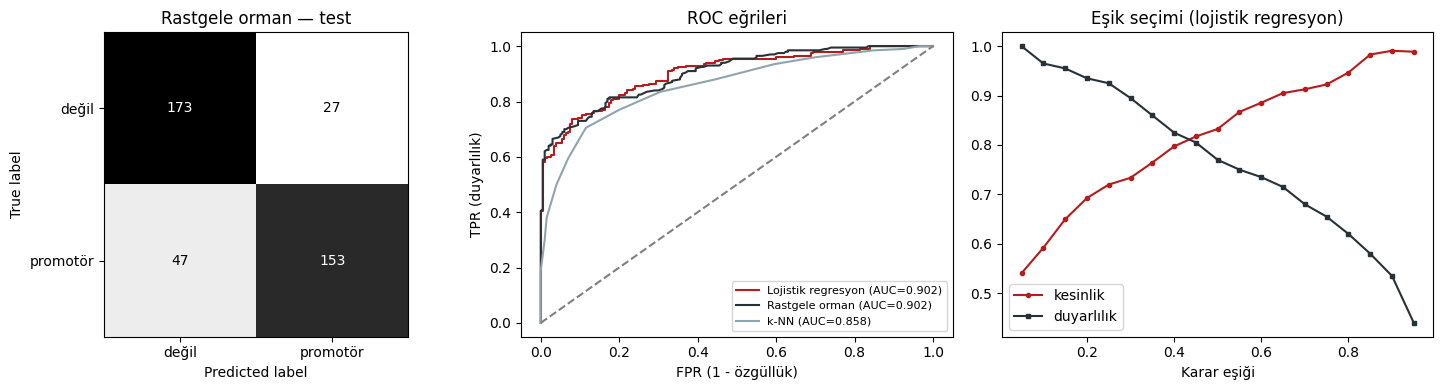

              precision    recall  f1-score   support

       değil       0.79      0.86      0.82       200
    promotör       0.85      0.77      0.81       200

    accuracy                           0.81       400
   macro avg       0.82      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



In [10]:
rf = modeller["Rastgele orman (300 ağaç)"]
lr = modeller["Lojistik regresyon"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=["değil", "promotör"], cmap="Greys", ax=ax[0], colorbar=False)
ax[0].set_title("Rastgele orman — test")
for ad, m, r in [("Lojistik regresyon", lr, "#b71c1c"), ("Rastgele orman", rf, "#263238"),
                 ("k-NN", modeller["k-NN (k=15)"], "#90a4ae")]:
    p = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[1].plot(fpr, tpr, color=r, label=f"{ad} (AUC={roc_auc_score(y_test, p):.3f})")
ax[1].plot([0, 1], [0, 1], "--", color="gray"); ax[1].set_xlabel("FPR (1 - özgüllük)"); ax[1].set_ylabel("TPR (duyarlılık)")
ax[1].legend(fontsize=8); ax[1].set_title("ROC eğrileri")
p = lr.predict_proba(X_test)[:, 1]
esikler = np.linspace(0.05, 0.95, 19)
ax[2].plot(esikler, [precision_score(y_test, p >= e, zero_division=0) for e in esikler], "o-", ms=3, label="kesinlik", color="#b71c1c")
ax[2].plot(esikler, [recall_score(y_test, p >= e) for e in esikler], "s-", ms=3, label="duyarlılık", color="#263238")
ax[2].set_xlabel("Karar eşiği"); ax[2].legend(); ax[2].set_title("Eşik seçimi (lojistik regresyon)")
plt.tight_layout(); plt.show()
print(classification_report(y_test, rf.predict(X_test), target_names=["değil", "promotör"]))

## 6. Çapraz doğrulama (k-fold cross-validation)
Eğitim verisi *k* parçaya bölünür; her seferinde biri doğrulama, kalanı eğitim için kullanılır. Ortalama ± standart sapma raporlanır.
Tek bir eğitim/test bölmesinin şansa bağlı olmasını azaltır.
```
Katman 1: [DOĞ][eğt][eğt][eğt][eğt]
Katman 2: [eğt][DOĞ][eğt][eğt][eğt]
   ...
Katman 5: [eğt][eğt][eğt][eğt][DOĞ]
```

In [11]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
ozellik_setleri = {"k=1 (bileşim)": X1, "k=2": X2, "k=3": X3, "k=4": X4, "sadece motif (3 özellik)": Xm,
                   "k=3 + motif": np.hstack([X3, Xm])}
sonuc = []
for ad, Xf in ozellik_setleri.items():
    for mad, m in [("LR", make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=3000))),
                   ("RF", RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1))]:
        s = cross_val_score(m, Xf, y, cv=cv, scoring="roc_auc")
        sonuc.append({"özellikler": ad, "model": mad, "AUC ort": s.mean(), "AUC std": s.std()})
tablo = pd.DataFrame(sonuc).pivot(index="özellikler", columns="model", values="AUC ort").round(3)
tablo

model,LR,RF
özellikler,,
k=1 (bileşim),0.794,0.730
k=2,0.815,0.800
k=3,0.826,0.829
k=3 + motif,0.899,0.889
k=4,0.842,0.857
sadece motif (3 özellik),0.816,0.832


> Biyolojik bilgiyle tasarlanmış **3 motif özelliği**, 64 ya da 256 boyutlu k-mer vektörleriyle yarışabiliyor; ikisinin birleşimi en iyisi.
Alan bilgisi (domain knowledge) + veri odaklı özellikler güçlü bir kombinasyondur.

## 7. Öğrenme eğrisi ve model karmaşıklığı

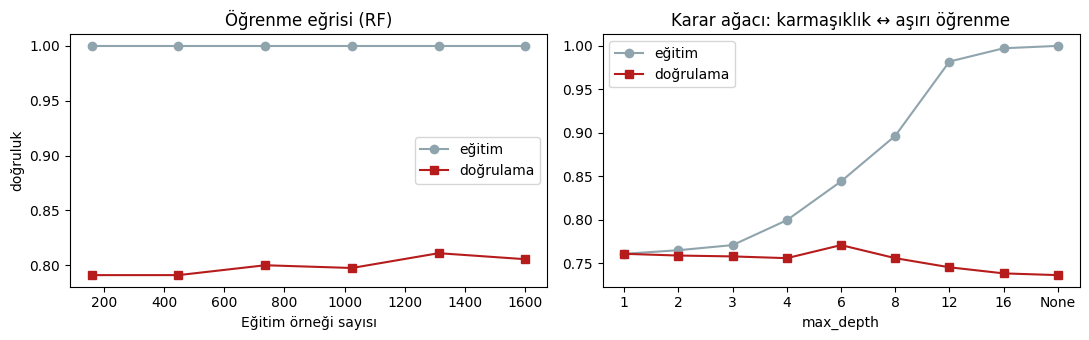

In [12]:
from sklearn.model_selection import learning_curve, validation_curve
X_best = np.hstack([X3, Xm])
boyut, egt_s, dog_s = learning_curve(RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1), X_best, y,
                                     cv=cv, train_sizes=np.linspace(0.1, 1.0, 6), scoring="accuracy")
derinlik = [1, 2, 3, 4, 6, 8, 12, 16, None]
tr, va = validation_curve(DecisionTreeClassifier(random_state=0), X_best, y, param_name="max_depth",
                          param_range=derinlik, cv=cv, scoring="accuracy")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(boyut, egt_s.mean(1), "o-", label="eğitim", color="#90a4ae"); ax[0].plot(boyut, dog_s.mean(1), "s-", label="doğrulama", color="#b71c1c")
ax[0].set_xlabel("Eğitim örneği sayısı"); ax[0].set_ylabel("doğruluk"); ax[0].legend(); ax[0].set_title("Öğrenme eğrisi (RF)")
xs = [str(d) for d in derinlik]
ax[1].plot(xs, tr.mean(1), "o-", label="eğitim", color="#90a4ae"); ax[1].plot(xs, va.mean(1), "s-", label="doğrulama", color="#b71c1c")
ax[1].set_xlabel("max_depth"); ax[1].legend(); ax[1].set_title("Karar ağacı: karmaşıklık ↔ aşırı öğrenme")
plt.tight_layout(); plt.show()

## 8. Modeli yorumlamak: hangi özellikler önemli?

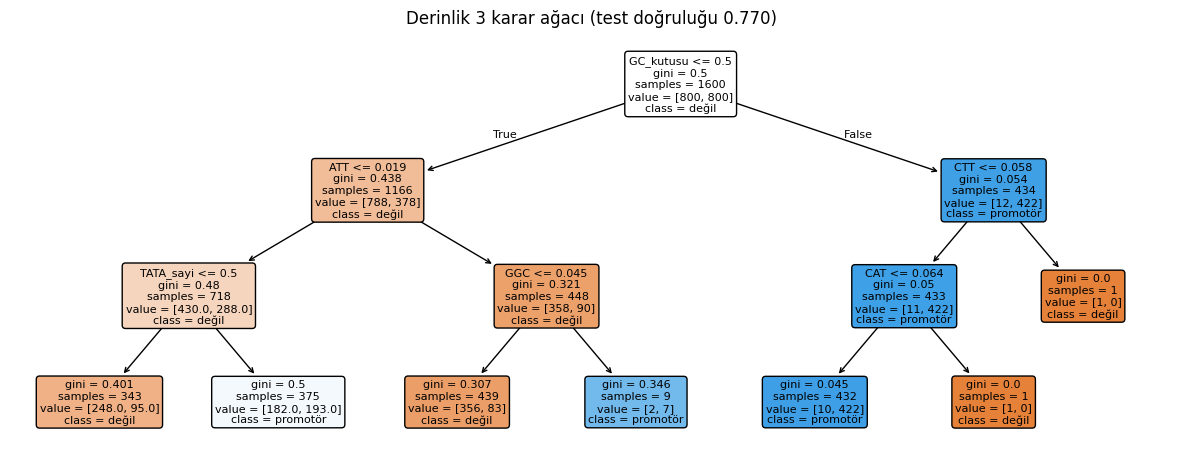

In [13]:
from sklearn.tree import plot_tree
agac = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_egt, y_egt)
plt.figure(figsize=(15, 5.5))
plot_tree(agac, feature_names=ozellik_adlari, class_names=["değil", "promotör"], filled=True, impurity=True, fontsize=8, rounded=True)
plt.title(f"Derinlik 3 karar ağacı (test doğruluğu {agac.score(X_test, y_test):.3f})"); plt.show()

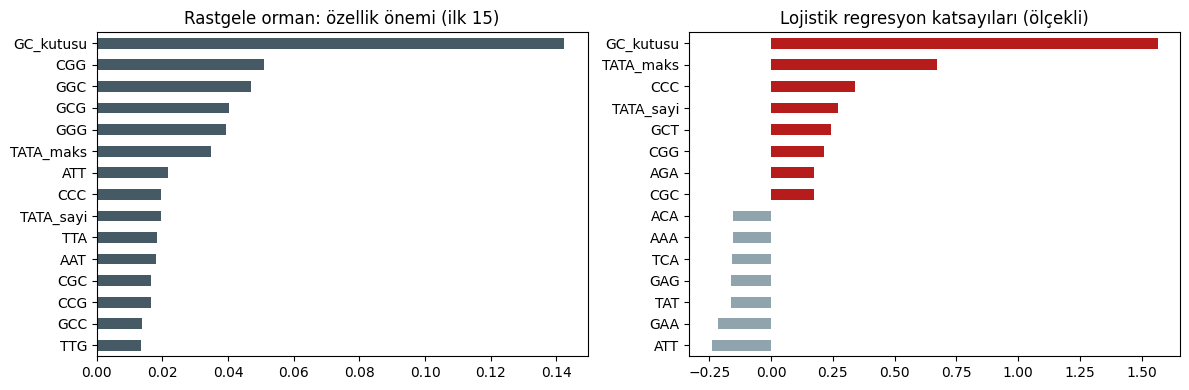

In [14]:
onem = pd.Series(rf.feature_importances_, index=ozellik_adlari).sort_values(ascending=False)
katsayi = pd.Series(lr[-1].coef_[0], index=ozellik_adlari).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
onem.head(15)[::-1].plot.barh(ax=ax[0], color="#455a64"); ax[0].set_title("Rastgele orman: özellik önemi (ilk 15)")
pd.concat([katsayi.head(7), katsayi.tail(8)]).plot.barh(ax=ax[1], color=["#90a4ae"] * 7 + ["#b71c1c"] * 8)
ax[1].set_title("Lojistik regresyon katsayıları (ölçekli)"); plt.tight_layout(); plt.show()

> Model, veri setini üretirken gömdüğümüz sinyalleri geri buldu: TATA motif skoru, `TAT`/`ATA` 3-merleri ve GC ile ilgili özellikler.
Gerçek biyolojide bu tür yorumlar **yeni hipotezler** üretmek için kullanılır (ör. yeni bir bağlanma motifi).

## 9. Hatalı sınıflandırılan örneklere bakmak

In [15]:
p_test = rf.predict_proba(X_test)[:, 1]
hatalar = pd.DataFrame({"dizi": veri.dizi.values[i_test], "gercek": y_test, "p": p_test.round(2),
                        "TATA_maks": X_test[:, -3].round(1), "GC_kutusu": X_test[:, -1]})
hatalar = hatalar[(hatalar.p >= 0.5) != (hatalar.gercek == 1)]
print("Hatalı sayısı:", len(hatalar))
hatalar.sort_values("p").head(8)

Hatalı sayısı: 76


,dizi,gercek,p,TATA_maks,GC_kutusu
11,GAACGGCAGTAAGCTGTAACTCAGATACACCTTACCGTATGCGGTT...,1,0.15,4.3,0.0
72,AGACTAGGGGAGAGTAGCGTTCTTCTGGATAGAGAAATCGTGTGTT...,1,0.19,2.3,0.0
318,CCTTACATCGTGCAATGAGAGATACACTATGTAAAAGGGTTAGGAG...,1,0.20,5.5,0.0
256,ATGTGTTAACGTCATTGCGGGACATCCCCGTAAGTTGTGGTTAACA...,1,0.23,4.3,0.0
110,AAACTTCTCGGCATCATCACCCCATTACCGTGAAGAAAATTTGCCT...,1,0.24,2.7,0.0
283,CAAAACTTTGTCGTCCGTGAAGTTCTAAGAACTAGTCTATGCGGTT...,1,0.24,4.3,0.0
200,GTTGAGAGGGAAAACTGCTGGTACATTATACATCAAAGTGGTTAAC...,1,0.26,5.8,0.0
245,GCTTGTATGGCAGTGGATAAATCGATCTTGACATTCACACATGCTC...,1,0.27,5.5,0.0


## 10. Alıştırmalar
1. TP = 90, FP = 30, FN = 10, TN = 870 için doğruluk, kesinlik, duyarlılık, özgüllük ve F1'i elle hesaplayın. Bu veri dengesiz mi? Doğruluk neden yanıltıcı olabilir?
2. Düğümde 12 pozitif, 4 negatif örnek var. Bir bölme bunu (10+, 0−) ve (2+, 4−) olarak ayırıyor. Gini kazancını hesaplayın.
3. k-NN için k = 1, 5, 15, 51, 151 değerlerinde 5 katlı çapraz doğrulama doğruluğunu çizin. Küçük ve büyük k'nın riskleri nelerdir?
4. Lojistik regresyonun düzenlileştirme parametresi C = 0.001 … 100 aralığında değişirken doğrulama AUC'sini çizin.
5. Özellikler rastgele karıştırılmış etiketlerle (y'yi `np.random.permutation` ile karıştırın) çapraz doğrulama yapın. Ne beklersiniz, ne buldunuz?

---
## Çözümler

1) doğruluk=0.960 kesinlik=0.750 duyarlılık=0.900 özgüllük=0.967 F1=0.818
   Pozitif oranı %10 -> 'hepsi negatif' diyen model bile %90 doğruluk alır.
2) G_kök=0.375, G_sol=0.000, G_sağ=0.444, kazanç=0.208


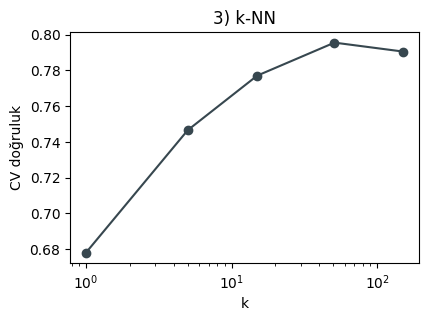

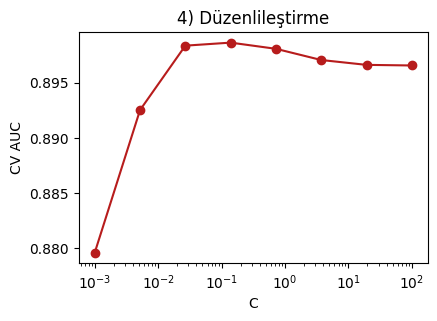

5) karıştırılmış etiket AUC: 0.508 (≈0.5 beklenir)


In [16]:
# 1
TP, FP, FN, TN = 90, 30, 10, 870
P, R = TP / (TP + FP), TP / (TP + FN)
print(f"1) doğruluk={(TP+TN)/1000:.3f} kesinlik={P:.3f} duyarlılık={R:.3f} özgüllük={TN/(TN+FP):.3f} F1={2*P*R/(P+R):.3f}")
print("   Pozitif oranı %10 -> 'hepsi negatif' diyen model bile %90 doğruluk alır.")
# 2
kok = gini(12, 4); sol = gini(10, 0); sag = gini(2, 4)
print(f"2) G_kök={kok:.3f}, G_sol={sol:.3f}, G_sağ={sag:.3f}, kazanç={kok - (10/16*sol + 6/16*sag):.3f}")
# 3
ks = [1, 5, 15, 51, 151]
sk = [cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(k)), X_best, y, cv=cv).mean() for k in ks]
plt.figure(figsize=(4.5, 3)); plt.semilogx(ks, sk, "o-", color="#37474f"); plt.xlabel("k"); plt.ylabel("CV doğruluk"); plt.title("3) k-NN"); plt.show()
# 4
Cs = np.logspace(-3, 2, 8)
auc = [cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(C=c, max_iter=3000)), X_best, y, cv=cv, scoring="roc_auc").mean() for c in Cs]
plt.figure(figsize=(4.5, 3)); plt.semilogx(Cs, auc, "o-", color="#b71c1c"); plt.xlabel("C"); plt.ylabel("CV AUC"); plt.title("4) Düzenlileştirme"); plt.show()
# 5
y_kar = np.random.default_rng(0).permutation(y)
print("5) karıştırılmış etiket AUC:", cross_val_score(RandomForestClassifier(200, random_state=0, n_jobs=-1), X_best, y_kar, cv=cv, scoring="roc_auc").mean().round(3), "(≈0.5 beklenir)")